Samples: 3924
Intents: 32


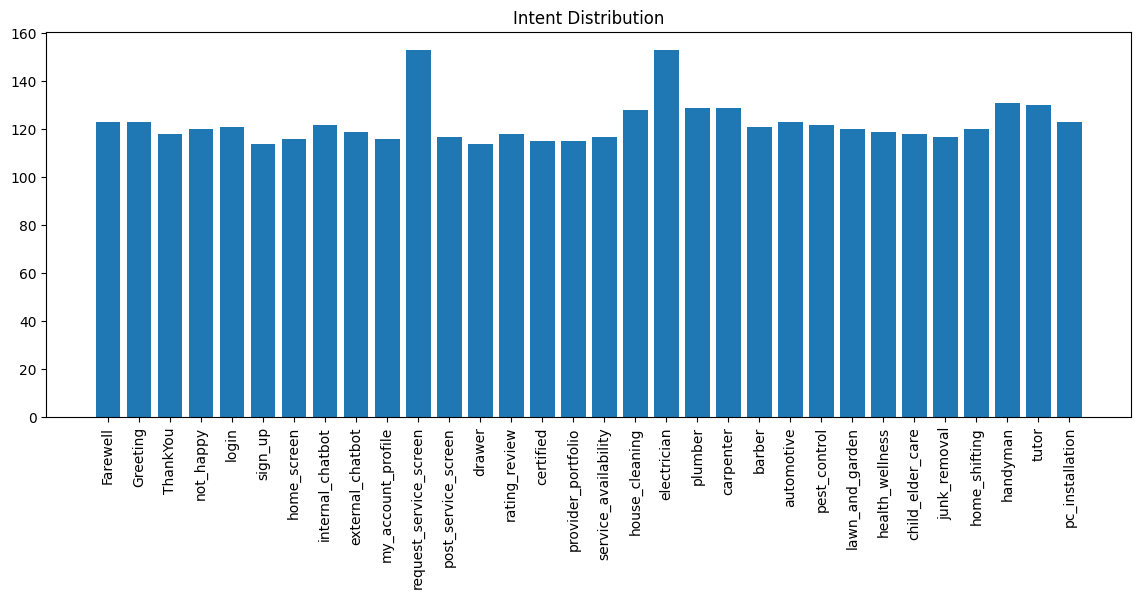

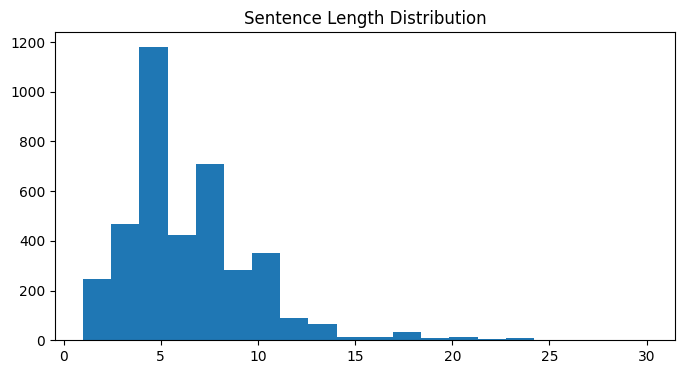

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 20, 32)         │       160,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_4      │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 32)             │         1,056 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 165,248 (645.50 KB)

 Trainable params: 165,248 (645.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
197/197 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.0379 - loss: 3.4644 - val_accuracy: 0.0471 - val_loss: 3.4560
Epoch 2/15
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0589 - loss: 3.4186 - val_accuracy: 0.0650 - val_loss: 3.3077
Epoch 3/15
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1080 - loss: 3.0343 - val_accuracy: 0.1758 - val_loss: 2.7645
Epoch 4/15
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1803 - loss: 2.5897 - val_accuracy: 0.3045 - val_loss: 2.3376
Epoch 5/15
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2717 - loss: 2.2557 - val_accuracy: 0.3478 - val_loss: 2.1587
Epoch 6/15
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3431 - loss: 1.9604 - val_accuracy: 0.5172 - val_loss: 1.7804
Epoch 7/15
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4396 - loss: 1.6878 - val_accuracy: 0.6051 - val_loss: 1.5580
Epoch 8/15
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5225 - loss: 1.4428 - val_accuracy: 0

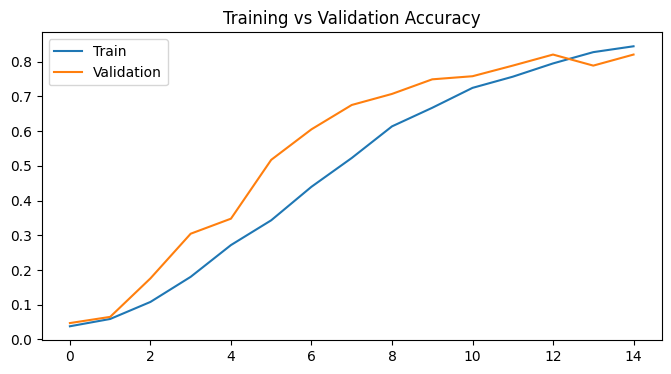

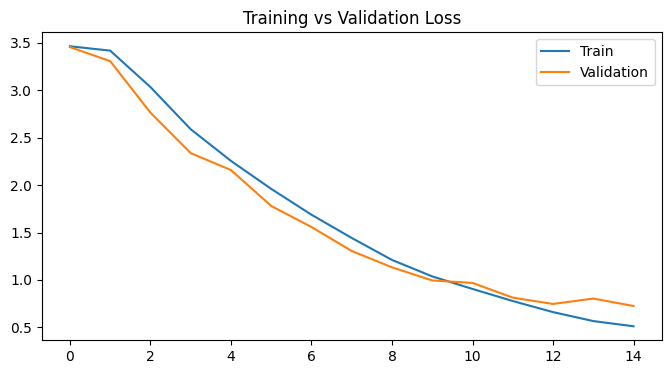

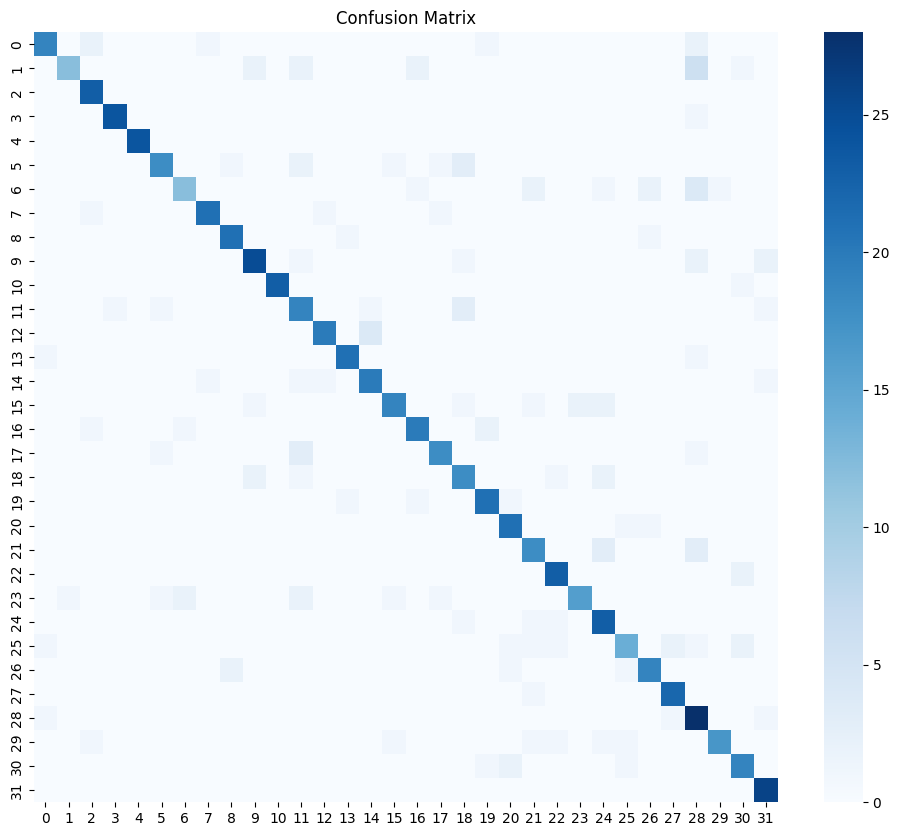

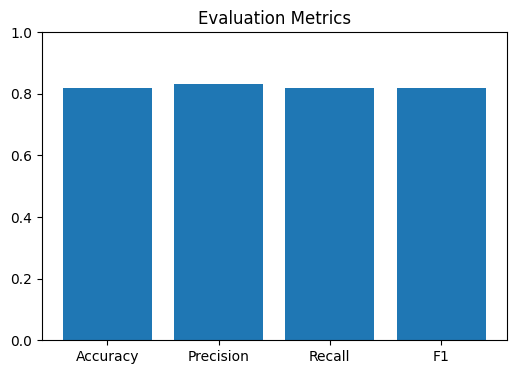

Saved artifact at '/tmp/tmp1d9h7419'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 20), dtype=tf.float32, name='keras_tensor_32')
Output Type:
  TensorSpec(shape=(None, 32), dtype=tf.float32, name=None)
Captures:
  133018507891856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133018507902416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133018507895504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133018507886672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133018507902224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133018507901264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133018507892048: TensorSpec(shape=(), dtype=tf.resource, name=None)

DONE


In [7]:
# ============================================================
# SMARTSERVE FINAL COMPLETE
# ============================================================

import json
import re
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Embedding,
    GlobalAveragePooling1D,
    Dense,
    Dropout
)

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.callbacks import EarlyStopping


# ============================================================
# DATASET
# ============================================================

DATA_PATH = "/content/smartserve_dataset_final.json"

with open(DATA_PATH, "r", encoding="utf-8") as f:
    data = json.load(f)

texts = []
labels = []
responses = {}


# ============================================================
# CLEAN
# ============================================================

def clean_text(text):

    text = text.lower().strip()

    text = re.sub(r"[^\w\s]", "", text)

    text = re.sub(r"\s+", " ", text)

    return text


# ============================================================
# READ
# ============================================================

for item in data["intents"]:

    intent = item["intent"]

    responses[intent] = item["responses"]

    for sentence in item["text"]:

        cleaned = clean_text(sentence)

        if cleaned != "":

            texts.append(cleaned)

            labels.append(intent)

print("Samples:", len(texts))
print("Intents:", len(set(labels)))


# ============================================================
# INTENT DISTRIBUTION
# ============================================================

intent_counts = {}

for item in labels:

    if item not in intent_counts:
        intent_counts[item] = 0

    intent_counts[item] += 1

plt.figure(figsize=(14,5))

plt.bar(
    intent_counts.keys(),
    intent_counts.values()
)

plt.xticks(rotation=90)

plt.title("Intent Distribution")

plt.show()


# ============================================================
# TOKENIZER
# ============================================================

VOCAB_SIZE = 5000
MAX_LEN = 20

tokenizer = Tokenizer(

    num_words=VOCAB_SIZE,

    oov_token="<OOV>"
)

tokenizer.fit_on_texts(texts)

sequences = tokenizer.texts_to_sequences(texts)

padded = pad_sequences(

    sequences,

    maxlen=MAX_LEN,

    padding="post"
)


# ============================================================
# SENTENCE LENGTH
# ============================================================

lengths = []

for s in sequences:
    lengths.append(len(s))

plt.figure(figsize=(8,4))

plt.hist(lengths, bins=20)

plt.title("Sentence Length Distribution")

plt.show()


# ============================================================
# LABELS
# ============================================================

label_encoder = LabelEncoder()

encoded_labels = label_encoder.fit_transform(labels)

num_classes = len(label_encoder.classes_)


# ============================================================
# SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(

    padded,

    encoded_labels,

    test_size=0.20,

    random_state=42,

    stratify=encoded_labels
)


# ============================================================
# MODEL
# ============================================================

model = Sequential([

    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=32
    ),

    GlobalAveragePooling1D(),

    Dense(
        64,
        activation="relu"
    ),

    Dropout(0.25),

    Dense(
        32,
        activation="relu"
    ),

    Dropout(0.15),

    Dense(
        num_classes,
        activation="softmax"
    )
])

model.build(input_shape=(None, MAX_LEN))

model.summary()


# ============================================================
# COMPILE
# ============================================================

model.compile(

    optimizer="adam",

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]
)


# ============================================================
# TRAIN
# ============================================================

early_stop = EarlyStopping(

    monitor="val_loss",

    patience=3,

    restore_best_weights=True
)

history = model.fit(

    X_train,
    y_train,

    validation_data=(X_test, y_test),

    epochs=15,

    batch_size=16,

    callbacks=[early_stop]
)


# ============================================================
# PREDICT
# ============================================================

y_pred_probs = model.predict(X_test)

y_pred = np.argmax(
    y_pred_probs,
    axis=1
)


# ============================================================
# METRICS
# ============================================================

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

print()
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

print()

print(classification_report(
    y_test,
    y_pred
))


# ============================================================
# ACCURACY GRAPH
# ============================================================

plt.figure(figsize=(8,4))

plt.plot(
    history.history["accuracy"],
    label="Train"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation"
)

plt.legend()

plt.title("Training vs Validation Accuracy")

plt.show()


# ============================================================
# LOSS GRAPH
# ============================================================

plt.figure(figsize=(8,4))

plt.plot(
    history.history["loss"],
    label="Train"
)

plt.plot(
    history.history["val_loss"],
    label="Validation"
)

plt.legend()

plt.title("Training vs Validation Loss")

plt.show()


# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(12,10))

sns.heatmap(
    cm,
    cmap="Blues"
)

plt.title("Confusion Matrix")

plt.show()


# ============================================================
# METRIC BAR CHART
# ============================================================

plt.figure(figsize=(6,4))

plt.bar(

    ["Accuracy","Precision","Recall","F1"],

    [accuracy, precision, recall, f1]
)

plt.ylim(0,1)

plt.title("Evaluation Metrics")

plt.show()


# ============================================================
# SAVE
# ============================================================

BASE_DIR = "/content/smartserve_export"

ORIGINAL_DIR = os.path.join(
    BASE_DIR,
    "original_model"
)

TFLITE_DIR = os.path.join(
    BASE_DIR,
    "tflite_model"
)

os.makedirs(
    ORIGINAL_DIR,
    exist_ok=True
)

os.makedirs(
    TFLITE_DIR,
    exist_ok=True
)

tokenizer_json = tokenizer.to_json()

for folder in [ORIGINAL_DIR, TFLITE_DIR]:

    with open(
        f"{folder}/tokenizer.json",
        "w"
    ) as f:
        f.write(tokenizer_json)

    with open(
        f"{folder}/classes.txt",
        "w"
    ) as f:

        for item in label_encoder.classes_:
            f.write(item + "\n")

    config = {
        "MAX_LEN": MAX_LEN,
        "VOCAB_SIZE": VOCAB_SIZE
    }

    with open(
        f"{folder}/config.json",
        "w"
    ) as f:
        json.dump(config, f)

    with open(
        f"{folder}/intent_responses.json",
        "w"
    ) as f:
        json.dump(responses, f)


model.save(
    f"{ORIGINAL_DIR}/smartserve_model.keras"
)

converter = tf.lite.TFLiteConverter.from_keras_model(model)

converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS
]

converter.inference_input_type = tf.float32
converter.inference_output_type = tf.float32

tflite_model = converter.convert()

with open(
    f"{TFLITE_DIR}/smartserve_model.tflite",
    "wb"
) as f:
    f.write(tflite_model)

shutil.make_archive(
    "/content/original_model_zip",
    "zip",
    ORIGINAL_DIR
)

shutil.make_archive(
    "/content/tflite_model_zip",
    "zip",
    TFLITE_DIR
)

print()
print("DONE")